## Project Introduction
This project builds a Real-Time Email Spam Detection System using Machine Learning techniques.

The goal is to classify emails as Spam (1) or Not Spam (0) based on word frequency patterns extracted from email text.

A Logistic Regression model is trained on a high-dimensional dataset containing word count features, and the final system is extended into a real-time API using Flask for live predictions.


Import Libraries
- pandas → Used for loading and handling structured dataset (CSV format)
- numpy → Provides numerical computing support
- train_test_split → Splits dataset into training and testing sets
- StandardScaler → Standardizes feature values for better model performance
- LogisticRegression → Classification model used for spam detection
- accuracy_score → Measures overall model correctness
- classification_report → Provides precision, recall, and F1-score
- confusion_matrix → Shows correct vs incorrect predictions

In [1]:
#Data manupilation and analysis
import pandas as pd
import numpy as np

### EDA

In [2]:
#load datasets from my file path
email = pd.read_csv(r"C:\Users\Administrator\Documents\Email Spam Classification\emails.csv")

#view first 5 rows
email.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [3]:
email.shape

(5172, 3002)

In [4]:
email.tail()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
5167,Email 5168,2,2,2,3,0,0,32,0,0,...,0,0,0,0,0,0,0,0,0,0
5168,Email 5169,35,27,11,2,6,5,151,4,3,...,0,0,0,0,0,0,0,1,0,0
5169,Email 5170,0,0,1,1,0,0,11,0,0,...,0,0,0,0,0,0,0,0,0,1
5170,Email 5171,2,7,1,0,2,1,28,2,0,...,0,0,0,0,0,0,0,1,0,1
5171,Email 5172,22,24,5,1,6,5,148,8,2,...,0,0,0,0,0,0,0,0,0,0


In [5]:
email.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB


In [6]:
email.describe()

,the,to,ect,and,for,of,a,you,hou,in,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
count,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,...,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000
mean,6.640565,6.188128,5.143852,3.075599,3.124710,2.627030,55.517401,2.466551,2.024362,10.600155,...,0.005027,0.012568,0.010634,0.098028,0.004254,0.006574,0.004060,0.914733,0.006961,0.290023
std,11.745009,9.534576,14.101142,6.045970,4.680522,6.229845,87.574172,4.314444,6.967878,19.281892,...,0.105788,0.199682,0.116693,0.569532,0.096252,0.138908,0.072145,2.780203,0.098086,0.453817
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,12.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,3.000000,1.000000,1.000000,2.000000,1.000000,28.000000,1.000000,0.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,7.000000,4.000000,3.000000,4.000000,2.000000,62.250000,3.000000,1.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,210.000000,132.000000,344.000000,89.000000,47.000000,77.000000,1898.000000,70.000000,167.000000,223.000000,...,4.000000,7.000000,2.000000,12.000000,3.000000,4.000000,3.000000,114.000000,4.000000,1.000000


In [7]:
#checking for missing values 
email.isnull().sum()

Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64

In [8]:
email.isnull().sum()

Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64

Key Observation
  - The dataset contains 5172 email samples
  - Each email is represented using 3000 word frequency features
  - The dataset is already numeric and suitable for machine learning
  - No missing values are present

## Feature Selection (X and y Definition)
separate the dataset into:

- Features (X): Input variables used to predict spam
- Target (y): The label we want to predict (Spam or Not Spam)


In [9]:
#define my target and features 
y = email["Prediction"].astype(int) #which is spam or not type spam label
x = email.drop(columns=["Prediction", "Email No."]) #the features are all the word columns, dropping the id column because I want the model to learn language patterns and not row numbers

print("Done")

Done


In [10]:
y

0       0
1       0
2       0
3       0
4       0
       ..
5167    0
5168    0
5169    1
5170    1
5171    0
Name: Prediction, Length: 5172, dtype: int64

In [11]:
x

,the,to,ect,and,for,of,a,you,hou,in,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
0,0,0,1,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,13,24,6,6,2,102,1,27,18,...,0,0,0,0,0,0,0,0,1,0
2,0,0,1,0,0,0,8,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,5,22,0,5,1,51,2,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,6,17,1,5,2,57,0,9,3,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5167,2,2,2,3,0,0,32,0,0,5,...,0,0,0,0,0,0,0,0,0,0
5168,35,27,11,2,6,5,151,4,3,23,...,0,0,0,0,0,0,0,0,1,0
5169,0,0,1,1,0,0,11,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5170,2,7,1,0,2,1,28,2,0,8,...,0,0,0,0,0,0,0,0,1,0


## Train-Test Split
split the dataset into two parts:

- Training set (80%) → used to teach the model patterns
- Testing set (20%) → used to evaluate performance on unseen data

This simulates how the model will perform in the real world.

also used stratification to ensure both sets maintain the same spam/non-spam ratio.

In [12]:
# Import train_test_split from sklearn
from sklearn.model_selection import train_test_split

# We use stratify=y to preserve the original proportion
# of spam and non-spam emails in both datasets.
# This helps the model learn and evaluate fairly,
# especially if the dataset classes are imbalanced.

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
) #state=42 every run produces the same split

# Display the shapes of the split datasets
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (4137, 3000)
Testing Features Shape: (1035, 3000)
Training Labels Shape: (4137,)
Testing Labels Shape: (1035,)


After splitting the dataset, the training feature set contains 4,137 email records with 3,000 word-based features, while the testing feature set contains 1,035 email records with the same 3,000 features.

The training labels (y_train) contain 4,137 corresponding target values indicating whether an email is spam or not spam, while the testing labels (y_test) contain 1,035 target values used for evaluating model performance.

Maintaining the same number of features in both datasets is important because the model expects the testing data to have the same structure as the training data during prediction.

## Feature Scaling
standardize the feature values so that all word frequency columns are on a similar scale.

This is especially important for Logistic Regression, because:
- it is sensitive to feature magnitude
- large-valued features can dominate smaller ones
- scaling improves convergence and stability

In [13]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler fitted on training data
# to transform the testing data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


Feature scaling helps normalize the feature values so that no single feature dominates the learning process due to larger numerical values. Since our dataset contains thousands of word-frequency features with varying counts, scaling helps improve optimization efficiency and model convergence during training.

We fitted the scaler only on the training dataset and then used the same fitted scaler to transform the testing dataset. This prevents data leakage and ensures that the model evaluates unseen data fairly.

Although the dataset is sparse and largely composed of zero values, scaling can still help Logistic Regression achieve more stable and efficient performance during model training.

## Model Selection & Training (Logistic Regression)
train a Logistic Regression model using the scaled training data.

This model learns patterns between word frequencies and email labels (Spam vs Not Spam).

We use Logistic Regression because:

- It works well with high-dimensional sparse data 3000 features
- It outputs probabilities (important for spam scoring)
- It is fast and interpretable

In [14]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# max_iter is increased to allow the model enough
# iterations to converge due to the large feature space

log_model = LogisticRegression(max_iter=1000)

# Train the model using the scaled training data
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Model Evaluation on Training Data
we evaluate the model performance on the training dataset to understand how well the model has learned patterns from the data.

In [15]:
# Predict on the training dataset
train_predictions = log_model.predict(X_train_scaled)

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate training accuracy
train_accuracy = accuracy_score(y_train, train_predictions)

print("Training Accuracy:", train_accuracy)

# Display classification report
print("\nClassification Report:\n")
print(classification_report(y_train, train_predictions))

# Display confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_train, train_predictions))

Training Accuracy: 0.9997582789460963

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2937
           1       1.00      1.00      1.00      1200

    accuracy                           1.00      4137
   macro avg       1.00      1.00      1.00      4137
weighted avg       1.00      1.00      1.00      4137


Confusion Matrix:

[[2936    1]
 [   0 1200]]


The model achieves near-perfect performance on the training dataset, indicating strong learning of word-frequency patterns associated with spam and non-spam emails. However, final model reliability is determined using the test dataset to ensure generalization to unseen data.

## Model Evaluation on Test Data (Final Validation)
evaluate the trained Logistic Regression model on the test dataset, which it has never seen before.

This simulates real-world performance on new incoming emails.

In [16]:
# Generate predictions on the testing dataset
# The model uses unseen email data from X_test_scaled

test_predictions = log_model.predict(X_test_scaled)

# Generate predicted probabilities
# Probability of class 1 (Spam)
test_probabilities = log_model.predict_proba(X_test_scaled)[:, 1]

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Calculate testing accuracy
test_accuracy = accuracy_score(y_test, test_predictions)

print("Testing Accuracy:", test_accuracy)

# Display classification report
print("\nClassification Report:\n")
print(classification_report(y_test, test_predictions))

# Display confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, test_predictions))

Testing Accuracy: 0.9690821256038648

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       735
           1       0.92      0.97      0.95       300

    accuracy                           0.97      1035
   macro avg       0.96      0.97      0.96      1035
weighted avg       0.97      0.97      0.97      1035


Confusion Matrix:

[[711  24]
 [  8 292]]


Precision (Spam) → How many predicted spam are actually spam
Recall (Spam) → How many real spam emails were detected
F1-score → Balanced measure of precision + recall

Model Evaluation Summary

Testing Accuracy: 96.9%

Correctly Classified Non-Spam Emails: 711
Correctly Classified Spam Emails: 292

False Positives: 24
False Negatives: 8

AUC Score: 0.9865079365079364


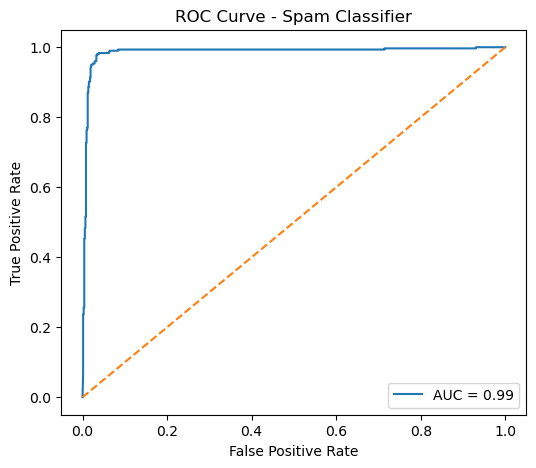

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities for class 1 (Spam)
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Compute AUC score
auc_score = roc_auc_score(y_test, y_probs)

print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Spam Classifier")
plt.legend()
plt.show()

The ROC (Receiver Operating Characteristic) curve was used to evaluate the model’s ability to distinguish between spam and non-spam emails across different classification thresholds.

The AUC (Area Under Curve) score provides a single value summary of model performance. A score closer to 1 indicates a strong classifier with good separation between classes.

## Model Saving (Serialization for Deployment)
save the trained machine learning components so they can be reused in your Flask API without retraining.

We save:

- Trained model
- Scaler
- Feature names

This ensures consistent predictions during real-time inference.

In [18]:
import pickle

# Save trained model
pickle.dump(log_model, open("spam_model.pkl", "wb"))

print("Model saved successfully.")

Model saved successfully.


In [19]:
StandardScaler

sklearn.preprocessing._data.StandardScaler

In [20]:
pickle.dump(scaler, open("scaler.pkl", "wb"))
print("Scaler saved successfully.")

Scaler saved successfully.
